Setup

In [1]:
%pip install pandas seaborn matplotlib numpy plotly folium

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import folium
from folium.plugins import HeatMap

## test/setup
#df_c = pd.read_csv('all_fires_full.csv')
df_p = pd.read_parquet('all_fires_full.parquet')

#print(df_c[['fire_name', 'alarm_date', 'gis_acres', 'vpd']].head())
#print(df_p[['fire_name', 'alarm_date', 'gis_acres', 'vpd']].head())


Find largest fire

In [15]:
largest_fire_name = df.loc[df['gis_acres'].idxmax(), 'fire_name']
max_acres = df['gis_acres'].max()

print(f"Largest Fire: {largest_fire_name} ({max_acres:,.0f} acres)")

# filter data for this specific fire's time series
fire_ts = df[df['fire_name'] == largest_fire_name].sort_values('days_to_ignition')


Largest Fire: AUGUST COMPLEX (1,032,700 acres)


Plot

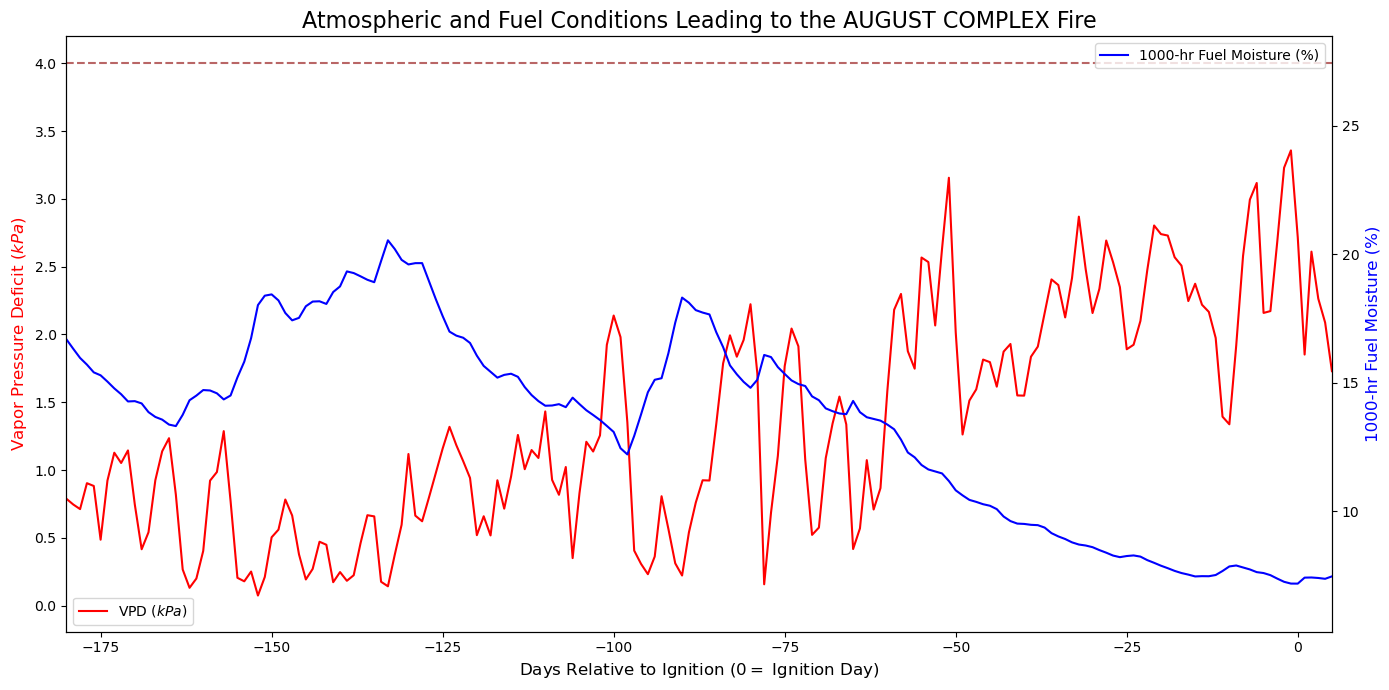

In [17]:
fig, ax1 = plt.subplots(figsize=(14, 7))

# plot vapor pressure deficit (VPD) - strongest fire predictor according to Data Dictionary
sns.lineplot(data=fire_ts, x='days_to_ignition', y='vpd', ax=ax1, color='red', label='VPD ($kPa$)')
ax1.set_ylabel('Vapor Pressure Deficit ($kPa$)', color='red', fontsize=12)
ax1.axhline(y=4, color='darkred', linestyle='--', alpha=0.6, label='Extreme Threshold (4 $kPa$)')

# second axis for fuel moisture (fm1000) - water content in vegetation (indicator for long term drought)
ax2 = ax1.twinx()
sns.lineplot(data=fire_ts, x='days_to_ignition', y='fm1000', ax=ax2, color='blue', label='1000-hr Fuel Moisture (%)')
ax2.set_ylabel('1000-hr Fuel Moisture (%)', color='blue', fontsize=12)

# formatting
plt.title(f'Atmospheric and Fuel Conditions Leading to the {largest_fire_name} Fire', fontsize=16)
ax1.set_xlabel('Days Relative to Ignition ($0 = $ Ignition Day)', fontsize=12)
ax1.set_xlim(-180, 5) # focus on the 6 months leading up
fig.tight_layout()
plt.show()

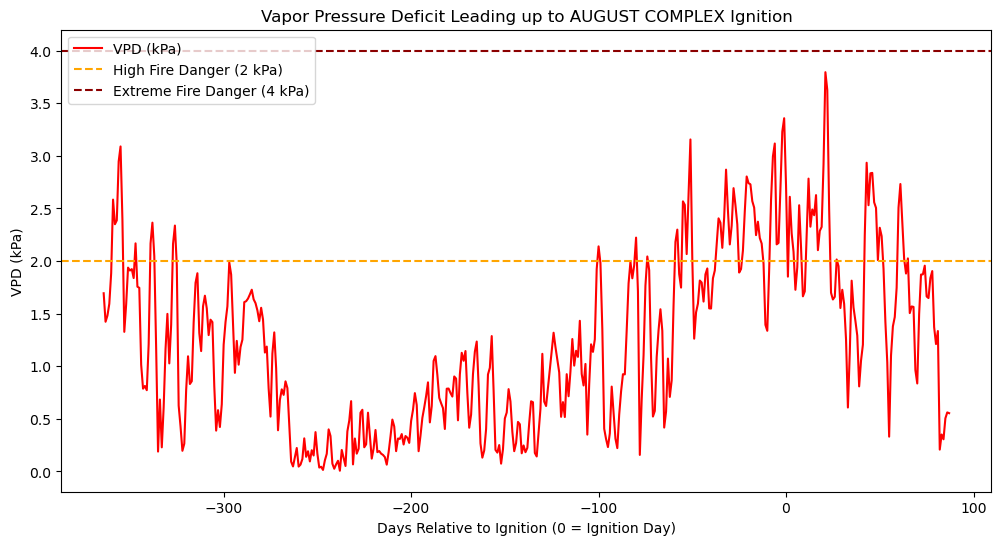

In [11]:
def plot_weather_leadup(fire_name):
    """
    Visualizes the lead up to a specific fire's ignition.
    """
    fire_data = df_p[df_p['fire_name'] == fire_name].sort_values('days_to_ignition')
    
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=fire_data, x='days_to_ignition', y='vpd', color='red', label='VPD (kPa)')
    
    # critical thresholds for vpd from dictionary
    plt.axhline(y=2, color='orange', linestyle='--', label='High Fire Danger (2 kPa)')
    plt.axhline(y=4, color='darkred', linestyle='--', label='Extreme Fire Danger (4 kPa)')
    
    plt.title(f'Vapor Pressure Deficit Leading up to {fire_name} Ignition')
    plt.xlabel('Days Relative to Ignition (0 = Ignition Day)')
    plt.ylabel('VPD (kPa)')
    plt.legend()
    plt.show()

# example
plot_weather_leadup('AUGUST COMPLEX')

Map(s)

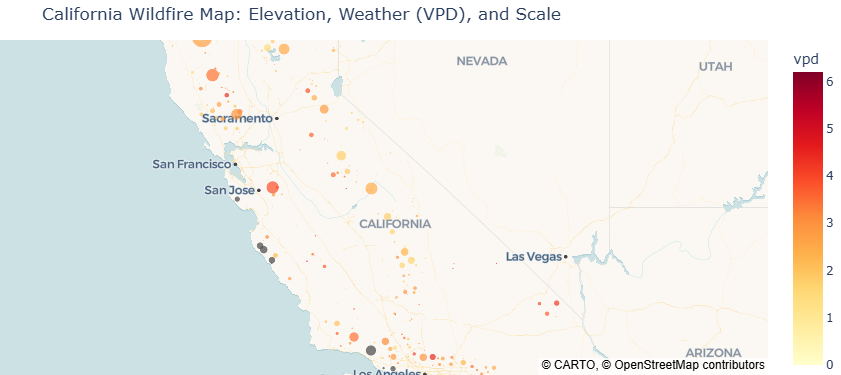

In [9]:
# conditions at time of ignition (days_to_ignition == 0)
ignition_data = df_p[df_p['days_to_ignition'] == 0].copy()

# create map
fig = px.scatter_map(
    ignition_data,
    lat="lat_centroid",
    lon="lon_centroid",
    # marker color represents VPD (can change)
    color="vpd", 
    # marker size represents fire scale
    size="gis_acres",
    # hover data includes elevation and temperature for more context (can change)
    hover_data=["fire_name", "elev_mean", "tmmx_c", "cause"],
    color_continuous_scale=px.colors.sequential.YlOrRd,
    size_max=15,
    zoom=5,
    center={"lat": 37, "lon": -119},
    title="California Wildfire Map: Elevation, Weather (VPD), and Scale"
)

# style for map background
fig.update_layout(mapbox_style="dark") 
fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})

fig.show()

In [8]:
# drop dupes to get unique fire events for map
unique_fires = df_p.drop_duplicates('fire_name')

# base map of cali
m = folium.Map(location=[37, -119], zoom_start=6, tiles='CartoDB positron')

# data for HeatMap [lat/long]
heat_data = unique_fires[['lat_centroid', 'lon_centroid']].values.tolist()

# add HeatMap layer
HeatMap(
    data=heat_data,
    name="Wildfire Density",
    radius=7,
    blur=5,
    min_opacity=0.3,
    max_zoom=12
).add_to(m)

m